<center>
<img src="https://raw.githubusercontent.com/FUlyankin/r_probability/master/end_seminars_2020/sem08/real_expect.png" width="800">

# Домашнее задание 3: Аварии на шахтах
</center>

## Общая информация

__Дата выдачи:__ 14.03.2026

__Дедлайн:__ 23:59MSK 05.04.2026

In [ ]:
import numpy as np

import scipy.stats as sts
import matplotlib.pyplot as plt
import math
plt.style.use('ggplot')  # стиль для графиков
%matplotlib inline

На угольных шахтах ежегодно происходят аварии. Англия довольно давно собирает информацию о числе крупных аварий. Именно её нам предстоит проанализировать:

* хочется понять как часто в среднем происходят аварии
* насколько большой у среднего числа аварий доверительный интервал

In [ ]:
import pandas as pd

df = pd.read_csv("coals.csv", index_col=0)
df.head()

,year,count
1,1851,4
2,1852,5
3,1853,4
4,1854,1
5,1855,0


В колонке `year` находится год наблюдений. В колонке `count` число аварий за этот год на шахтах в Англии. Посмотрим на распределение числа аварий.

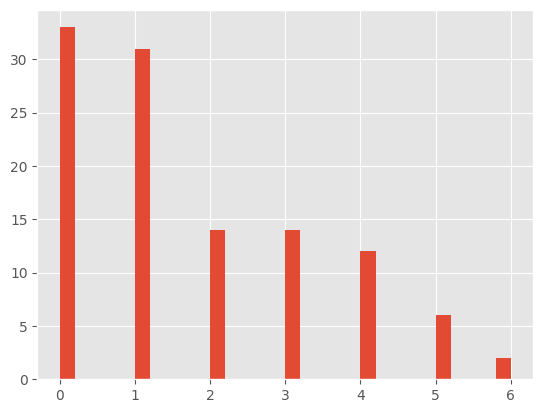

In [ ]:
df['count'].hist(bins=30);

Судя по гистограмме уместно предположить, что число аварий имеет распределение Пуассона, $Poiss(\lambda)$.  То есть, если мы хотим что-то понять про среднее число аварий, нам надо оценить параметр $\lambda$.

__а) Метод моментов__

Найдите оценку параметра $\lambda$ с помощью метода моментов. Запишите получившийся результат в переменную `lambda_hat`.

In [ ]:
n_hat = df.shape[0]   # число наблюдений
lam_hat = df['count'].mean()       # ваша оценка метода моментов

print('число наблюдений = ', n_hat)
print('оценка параметра lambda = ', lam_hat)

число наблюдений =  112
оценка параметра lambda =  1.7053571428571428


__б) Стандартное отклонение__

Среднее, оценённое методом моментов будет иметь асимптотически нормальное распределение. Оцените стандартное отклонение этого распределения по выборке и запишите ответ в переменную `lam_se`.

> __Примечание:__ мы предполагаем, что выборка пришла из распределения Пуассона. Для него $Var(X) = \lambda$. Для оценки стандартного отклонения используйте этот факт. Конечно же вы можете оценить его через функцию `std`, в плане асимптотики результат получится одинаковый. Оба способа корректны. Но с точки зрения грейдера, у вас будет ошибка.

In [ ]:
lam_se = np.sqrt(lam_hat/n_hat)

print("Стандартное отклонение = ", lam_se)


Стандартное отклонение =  0.1233953121525469


__в) Доверительный интервал__

Постройте для неизвестного математического ожидания $\lambda$ доверительный интервал. Возьмите уровень значимости равный $10\%$. В переменные `left` и `right` запишите соотвествующие границы интервала. В переменную `delta` запишите его ширину.

In [ ]:
alpha = 0.1
z_alpha = sts.norm.ppf(1 - alpha/2)

left = lam_hat-z_alpha*lam_se
right = lam_hat + z_alpha*lam_se
delta = right-left

print(f"90% доверительный интервал для лямбды: [{left}, {right}]")
print(f"Ширина интервала: {delta}")

90% доверительный интервал для лямбды: [1.502389916114217, 1.9083243696000687]
Ширина интервала: 0.4059344534858518


__г) Число катастроф__  

Многие говорят, что в $20$ веке катастроф стало на порядок меньше. Давайте проверим это. Постройте оценку для $\lambda_1$ по данным до $1900$ года включительно. Постройте оценку для $\lambda_2$ по данным после $1900$ года. Для разности $\lambda_1 - \lambda_2$ постройте $95\%$ доверительный интервал.

In [ ]:
x = df[df.year <= 1900]['count']
y = df[df.year > 1900]['count']

lam_1 = x.mean()
lam_2= y.mean()
n1, n2 = x.shape[0], y.shape[0]

alphz_alpha = sts.norm.ppf(1 - alpha/2)
diff_se = np.sqrt(lam_1/n1 + lam_2/n2)

left = (lam_1-lam_2) - z_alpha*diff_se
right = (lam_1-lam_2) + z_alpha*diff_se
delta = right - left

print(f" лямбда 1 (до 1900): {lam_1:.4f}")
print(f" лямбда 2 (после 1900): {lam_2:.4f}")
print(f" 95% доверительный интервал для разности: [{left:.4f}, {right:.4f}]")
print(f" Ширина интервала: {delta:.4f}")
print(f" Ноль {'не ' if left > 0 or right < 0 else ''} входит в интервал")


 лямбда 1 (до 1900): 2.7000
 лямбда 2 (после 1900): 0.9032
 95% доверительный интервал для разности: [1.3661, 2.2275]
 Ширина интервала: 0.8614
 Ноль не  входит в интервал


Ноль не вошёл в этот доверительный интервал. Это означает, что на уровне значимости $5\%$ мы можем сказать, что число аварий правда снизилось.

__д) Вероятность для распределения Пуассона__

Вспомните формулу, по которой считается вероятность того, что Пуассоновская случайная величина примет какое-то значение. Найдите точечную оценку вероятности того, что произойдёт только одна авария. В качестве $\lambda$ используйте оценку метода моментов, полученную в первом задании.

In [ ]:
def poiss_prob(k):
  return (lam_hat**k * np.exp(-lam_hat)) / math.factorial(k)

prob_1 = poiss_prob(1)
print(f" Вероятность одной аварии P(X=1) = {prob_1}")


 Вероятность одной аварии P(X=1) = 0.3098761473208731


__е) Дельта-метод__

Та вероятность, которую мы нашли в предыдущем пункте - это лишь точечная оценка. Она является функцией от среднего. С помощью дельта-метода постройте для этой вероятности $95\%$ довертельный интервал.

In [ ]:
alpha = 0.5
z_alpha = sts.norm.ppf(1 - alpha/2)

derivative = np.exp(-lam_hat) * (1 - lam_hat)
se_prob = np.abs(derivative) * lam_se

left = poiss_prob(1) - z_alpha * se_prob
right = poiss_prob(1) + z_alpha * se_prob
delta = right - left

print(f"95% доверительный интервал для P(X=1): [{left}, {right}]")
print(f"Ширина интервала: {delta:.6f}")


95% доверительный интервал для P(X=1): [0.299208813472887, 0.32054348116885917]
Ширина интервала: 0.021335


По аналогии можно построить доверительные интервалы для вероятности того, что случайная величина примет значения от нуля до девяти. Проделайте это в качестве необязательного упражнения и оформите процедуру расчёта в виде функции.

In [ ]:
def prob_ci(k, alpha = 0.01, lam_hat=lam_hat):
  k_array = np.atleast_1d(k)
  probs = np.exp(-lam_hat) * (lam_hat ** k_array) / np.array([math.factorial(int(kk)) for kk in k_array])
  derivatives = probs * (k_array / lam_hat - 1)

  lam_se = np.sqrt(lam_hat / df.shape[0])
  se_probs = np.abs(derivatives) * lam_se

  z_critical = sts.norm.ppf(1 - alpha/2)

  left = probs - z_critical * se_probs
  right = probs + z_critical * se_probs

  if np.isscalar(k):
      return left[0], right[0]

  return left, right

left, right = prob_ci(1, alpha=0.05)
print(f"Для k=1: [{left}, {right}]")


Для k=1: [0.27887850777625484, 0.34087378686549136]


In [ ]:
left, right = prob_ci(1)
delta = right - left

assert np.abs(delta - 0.08147) < 1e-5

left, right = prob_ci(0)
delta = right - left

assert np.abs(delta - 0.11551) < 1e-5

Сделали функцию? Запускайте код для не очень информативной картинки!

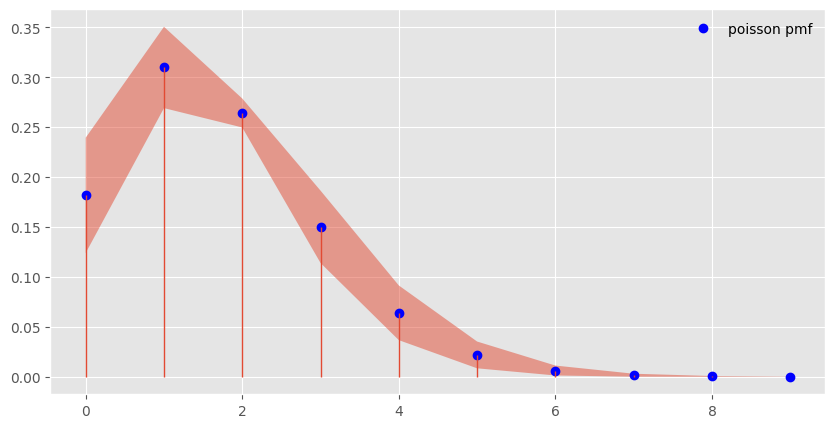

In [ ]:
poiss_rv = sts.poisson(lam_hat)

x = np.arange(10)

p = poiss_rv.pmf(x)
left, right = prob_ci(x)

plt.figure(figsize=(10,5))
plt.plot(x, p, 'bo', ms=6, label='poisson pmf')
plt.fill_between(x, left, right, alpha=0.5)
plt.vlines(x, 0, p, lw=1)
plt.legend(loc='best', frameon=False)
plt.show()

In [ ]:
for k,(i,j) in enumerate(zip(left, right)):
    print(f"Вероятность P(X={k}) лежит между  {i:.5} и {j:.5}")

Вероятность P(X=0) лежит между  0.12395 и 0.23946
Вероятность P(X=1) лежит между  0.26914 и 0.35061
Вероятность P(X=2) лежит между  0.24971 и 0.27873
Вероятность P(X=3) лежит между  0.11396 и 0.18644
Вероятность P(X=4) лежит между  0.036649 и 0.091422
Вероятность P(X=5) лежит между  0.0084293 и 0.035252
Вероятность P(X=6) лежит между  0.0012388 и 0.011177
Вероятность P(X=7) лежит между  1.9936e-05 и 0.0030047
Вероятность P(X=8) лежит между  -5.5837e-05 и 0.00070061
Вероятность P(X=9) лежит между  -2.1966e-05 и 0.00014414


Интервалы получился довольно короткими. Попробуйте поиграться с уровнем значимости и посмотреть как они меняются в зависимости от него.

В этой терадке нам осталось обсудить последний нюанс. Мы из теории вероятностей знаем, что для случайной величины $X$, имеющей распределение Пуассона $\mathbb{E}(X) = Var(X) = \lambda$. Для текущей выборки мы видим, что между дисперсией и средним есть небольшое отличие.

In [ ]:
df['count'].mean()

np.float64(1.7053571428571428)

In [ ]:
df['count'].var()

2.7142052767052722

Не факт, что мы имеем право предполагать, что наша выборка пришла к нам из распределения Пуассона. Все предпосылки о распределениях выборки нужно тестировать. Позже мы научимся это делать.